In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from scipy.ndimage import labeled_comprehension
from skimage.measure import block_reduce
from skimage.segmentation import slic


## Chocolate Segmentation
The purpose of this section is to extract a binary mask that separates all chocolates from the background to then be postprocessed and fed to a the feature extraction methods and finally the classifier. Our intent was to continue to explore the concepts presented in the lectures, and test our ability to produce a pipeline that could extend to more backgrounds and chocolates. We therefore went for a selection of clustering techniques instead of manually tuned thresholds, which has proven to be more challenging than expected. Although it allowed us to experiment with more methods and face some new problematics, it didn't provide robust results for the rest of the pipeline and probably had a negative impact of the final score.

### Reduction of data

The 24MPX resolution of the provided images is overkill compared to the amount of information we want to extract out of them. We therefore decided to reduce their size to lighten the rest of the pipeline. This is done by binning the images with a square (10,10) median kernel, dividing by 100 the amount of data. Median is preferred to mean filtering as it preserves edges better.

In [3]:
def median_bin_rgb(image, block_size=(2, 2)):
    channels = []
    for i in range(3):
        channel = block_reduce(image[:, :, i], block_size=block_size, func=np.median)
        channels.append(channel)
    return np.stack(channels, axis=-1).astype(np.uint8)

In [4]:
train_data_path = '../data/dataset_project_iapr2025/train'
full_path = train_data_path + '/L1010026.JPG'

img = np.array(Image.open(full_path))
binned = median_bin_rgb(img, block_size=(10, 10))

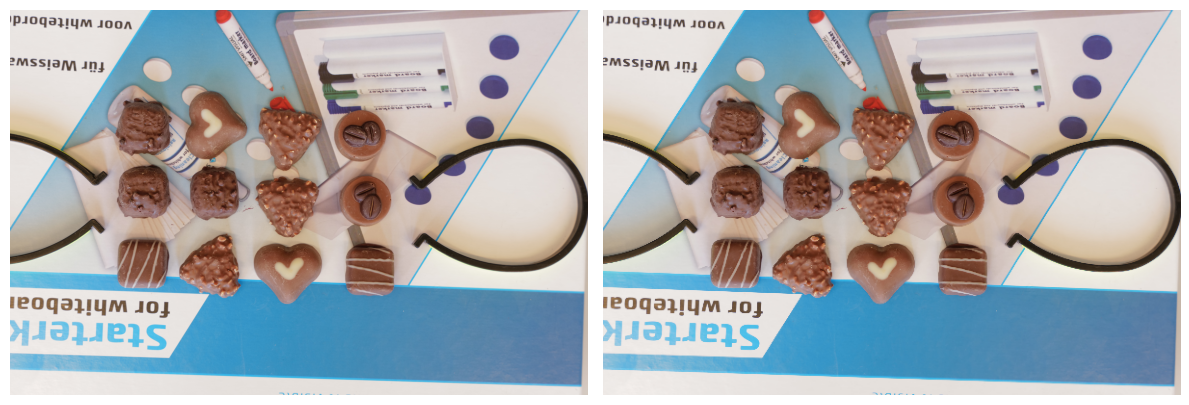

original shape: (4000, 6000, 3)
reduced shape: (400, 600, 3)


In [7]:
plt.figure(figsize=(12, 7))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(binned)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'original shape: {img.shape}\nreduced shape: {binned.shape}')

### Super pixels
SLIC (Simple Linear Iterative Clustering) is a method cluster the pixels in the image into numerous superpixels, based on their color and location. Since the higher level clustering techniques we employ to separate chocolate from background only depend on the color information of the pixels, dividing the image in superpixels allows us to extract some of the spatial information in the image. This helps avoid high frequency noise in the binary mask after clustering, and align the segmentation with the edges of the chocolate in the spatial domain. We can roughly control the amount of superpixels, as well as the ratio of importance between color and spatial information for clustering (compactness)

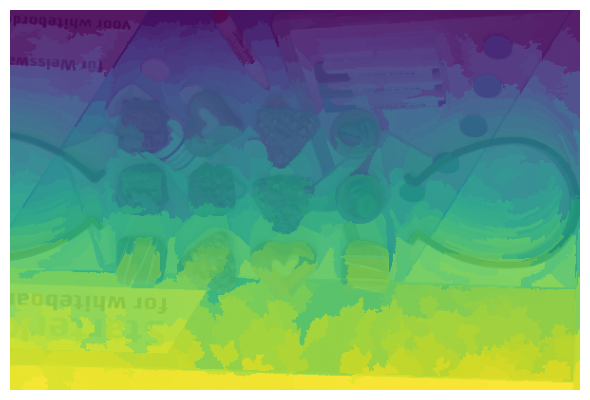

In [17]:
spx = slic(binned, n_segments=1000, compactness=.05, sigma=0.1, start_label=0)

plt.figure(figsize=(6, 8))

plt.imshow(binned)
plt.imshow(spx, alpha=0.9)
plt.axis('off')

plt.tight_layout()
plt.show()

### Low level extraction
We convert remap the image from rgb to hsv because the different kind of milk and dark chocolates lie in a small range of hue values, and this space is slightly less sensitive to lighting conditions (reflects from sideways light were a big problem in rgb). Because hue is an angle, some colors near the minimum value are actually close to colors near the maximum value ([0, 180] for the cv2 implementation). Since the hue of the chocolates lies near those extremas we need a way to wrap the hue values to be able to cluster chocolates together. We therefore split the hue into two components $h_x$ and $h_y$, respectively cosine and sine of $h$. We normalize h, s and v values so that they are in the range [0,1]. Each superpixel takes the median of those features over the pixels it contains.

In [24]:
binned_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
binned_hsv = cv2.cvtColor(binned_bgr, cv2.COLOR_BGR2HSV)

In [25]:
def hsv_spx_feat(hsv_img, spx, agg_func=np.median):    
    label_ids = np.arange(spx.max() + 1)        
    h = labeled_comprehension(hsv_img[..., 0],labels=spx,index=label_ids,func=agg_func,out_dtype=float,default=np.nan)/180 #cv2 convention
    s = labeled_comprehension(hsv_img[..., 1],spx,label_ids,func=agg_func,out_dtype=float,default=np.nan)/255
    v = labeled_comprehension(hsv_img[..., 2],spx,label_ids,func=agg_func, out_dtype=float,default=np.nan)/255

    hx = np.cos(h*2*np.pi)
    hy = np.sin(h*2*np.pi)

    feat = np.array([hx, hy, s, v])
    return feat.T

In [26]:
hsv_feat = hsv_spx_feat(binned_hsv, spx, np.median)

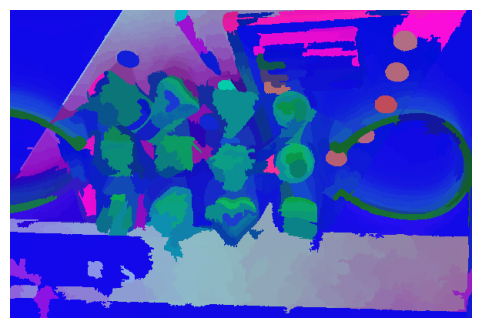

In [ ]:
h = (np.atan2(hsv_feat[:,1], hsv_feat[:,0])/(2*np.pi))%1 #unwrap h
unwrapped_feat = np.vstack((h, hsv_feat[:,2], hsv_feat[:,3])).T

plt.figure(figsize=(6,4))
plt.imshow(unwrapped_feat[spx])
plt.axis('off')
plt.show()